In [1]:
import pandas as pd
import numpy as np

# [0단계] 데이터 불러오기
df = pd.read_csv('소상공인시장진흥공단_상가(상권)정보_서울_202306.csv')

# [1단계] 마포구만 필터링
df_mapo_raw = df[(df['시군구코드'] == 11440) | (df['시군구명'] == '마포구')].copy()

# [2단계] 3순위까지의 핵심 7개 컬럼 추출
essential_cols = ['시군구명', '행정동명', '상권업종중분류명', '경도', '위도', '건물명', '상호명']
df_clean = df_mapo_raw[essential_cols].copy()


# =========================================================
# 🔥 [핵심 고치기] 에러를 방지하는 철벽 전처리 구역
# =========================================================
# 1. 오직 '글자'만 들어있는 컬럼 이름들만 따로 지정합니다.
text_cols = ['시군구명', '행정동명', '상권업종중분류명', '건물명', '상호명']

# 2. 이 글자 컬럼들만 안전하게 문자열로 바꾸고 공백을 지웁니다.
# (경도, 위도는 이 반복문에서 제외되므로 .str 에러가 절대 나지 않습니다!)
for col in text_cols:
    df_clean[col] = df_clean[col].astype(str).str.strip()

# 3. 빈 칸 처리 및 결측치 정리
df_clean = df_clean.replace({'nan': np.nan, '': np.nan})
df_clean['상호명'] = df_clean['상호명'].fillna("정보없음")
df_clean['건물명'] = df_clean['건물명'].fillna("정보없음")

# 4. 필수 정보(동, 업종, 좌표)가 없는 행만 삭제
df_clean = df_clean.dropna(subset=['시군구명', '행정동명', '상권업종중분류명', '경도', '위도'])


# =========================================================
# [3단계] 머신러닝용 밀집도 변환 (글자 떼어내기)
# =========================================================
# pd.crosstab을 쓰면 '행정동명'은 왼쪽 인덱스(행 이름)로 가고, 
# '상권업종중분류명'은 상단 컬럼(열 이름)으로 가면서 안쪽은 자동으로 '숫자(개수)'만 남습니다.
pivot_mapo = pd.crosstab(df_clean['행정동명'], df_clean['상권업종중분류명'])

# 비율(밀집도)로 변환
density_mapo = pivot_mapo.div(pivot_mapo.sum(axis=1), axis=0)

print("🎉 에러 없이 완벽하게 성공했습니다!")
print(density_mapo.head())

🎉 에러 없이 완벽하게 성공했습니다!
상권업종중분류명     가구 소매  가전·통신 소매   가전제품 수리   가정용품 대여     고용 알선        광고  \
행정동명                                                                   
공덕동       0.007782  0.009079  0.002594  0.001946  0.007782  0.025292   
대흥동       0.000854  0.014518  0.004270  0.002562  0.006832  0.020495   
도화동       0.000000  0.007341  0.000000  0.004078  0.012235  0.046493   
망원1동      0.002736  0.008892  0.003420  0.002736  0.002052  0.029412   
망원2동      0.005447  0.013072  0.004357  0.002179  0.004357  0.035948   

상권업종중분류명     교육 지원   구내식당·뷔페    기술 서비스  기타 가정용품 수리  ...     종합 소매        주점  \
행정동명                                                ...                       
공덕동       0.008431  0.003243  0.039559    0.007782  ...  0.033722  0.031128   
대흥동       0.021349  0.005124  0.011956    0.005978  ...  0.036721  0.027327   
도화동       0.013051  0.002447  0.012235    0.004894  ...  0.026101  0.064437   
망원1동      0.004104  0.000000  0.017100    0.008208  ...  0.034200  0.037620   


/var/folders/wb/hx3526hj6kbbc8hs3t8fv03m0000gn/T/ipykernel_26884/3911485964.py:5: DtypeWarning: Columns (0: 지점명) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('소상공인시장진흥공단_상가(상권)정보_서울_202306.csv')


In [2]:
density_mapo.to_csv('마포구_업종_밀집도_머신러닝용.csv', index=True, encoding='utf-8-sig')

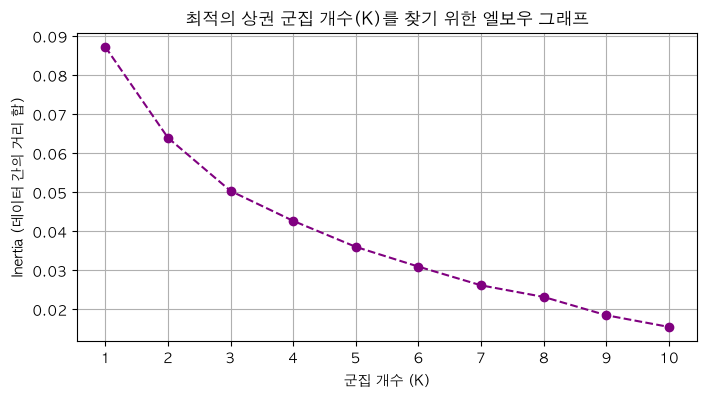

💡 그래프의 꺾이는 지점(경사가 완만해지는 팔꿈치 지점)을 보고 K를 결정합니다. 보통 3~4개가 적당합니다.

🎉 K-Means 학습 완료! 마포구 행정동별 상권 분류 결과:
▶ [군집 0]에 묶인 동네 (3개 동): ['도화동', '상암동', '용강동']
▶ [군집 1]에 묶인 동네 (5개 동): ['망원1동', '서강동', '서교동', '성산1동', '합정동']
▶ [군집 2]에 묶인 동네 (7개 동): ['공덕동', '대흥동', '망원2동', '성산2동', '신수동', '아현동', '염리동']
▶ [군집 3]에 묶인 동네 (1개 동): ['연남동']


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. 그래프에서 한글 깨짐 방지 설정
plt.rcParams['font.family'] = 'AppleGothic' # 윈도우 사용자 (맥은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# =========================================================
# [1단계] 엘보우 방법(Elbow Method)으로 최적의 군집 개수(K) 찾기
# =========================================================
# 군집 개수를 1개부터 10개까지 늘려가며 컴퓨터에게 테스트를 시킵니다.
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(density_mapo)  # 오직 숫자(비율)만 있으므로 에러 없이 작동합니다!
    inertia.append(kmeans.inertia_)

# 엘보우 그래프 그리기
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', linestyle='--', color='purple')
plt.title('최적의 상권 군집 개수(K)를 찾기 위한 엘보우 그래프')
plt.xlabel('군집 개수 (K)')
plt.ylabel('Inertia (데이터 간의 거리 합)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

print("💡 그래프의 꺾이는 지점(경사가 완만해지는 팔꿈치 지점)을 보고 K를 결정합니다. 보통 3~4개가 적당합니다.")


# =========================================================
# [2단계] 선택한 K값으로 실제 K-Means 모델 학습 및 군집 예측
# =========================================================
# 엘보우 그래프를 보고 가장 적절해 보이는 군집 수(예: 4개)를 지정합니다.
BEST_K = 4
model = KMeans(n_clusters=BEST_K, init='k-means++', random_state=42)

# 모델 학습과 동시에 각 행정동이 몇 번 군집인지(0, 1, 2, 3) 예측 결과 반환
cluster_labels = model.fit_predict(density_mapo)

# 기존 밀집도 데이터프레임에 '상권_군집'이라는 결과 컬럼 추가
density_mapo['상권_군집'] = cluster_labels


# =========================================================
# [3단계] 머신러닝 결과 확인하기
# =========================================================
print("\n=========================================================")
print(f"🎉 K-Means 학습 완료! 마포구 행정동별 상권 분류 결과:")
print("=========================================================")
for c in range(BEST_K):
    # 각 군집 번호에 속한 행정동 이름들을 리스트로 뽑아냅니다.
    dong_list = density_mapo[density_mapo['상권_군집'] == c].index.tolist()
    print(f"▶ [군집 {c}]에 묶인 동네 ({len(dong_list)}개 동): {dong_list}")

In [4]:
# density_mapo.to_csv('마포구_업종_밀집도_머신러닝용.csv', index=True, encoding='utf-8-sig')


In [ ]:
# import sys
# !{sys.executable} -m pip install --upgrade pip
# !{sys.executable} -m pip install folium

In [7]:
import pandas as pd
import numpy as np
import folium
from folium.plugins import MarkerCluster
from sklearn.cluster import KMeans

# =========================================================
# [1단계] 지도용 마스터 데이터 불러오기 및 텍스트 정제
# =========================================================
print("1. 데이터를 불러오는 중입니다...")
df_gis = pd.read_csv('마포구_점포_마스터_지도용.csv')

# 혹시 모를 글자 공백 제거
text_cols = ['시군구명', '행정동명', '상권업종중분류명', '건물명', '상호명']
for col in text_cols:
    df_gis[col] = df_gis[col].astype(str).str.strip()

# =========================================================
# [2단계] 코드 내부에서 즉석 밀집도 계산 및 K-Means 학습
# =========================================================
print("2. 업종 밀집도를 계산하고 머신러닝(K-Means)을 실행합니다...")

# 행정동별 업종 개수 피벗 테이블 생성
pivot_mapo = pd.crosstab(df_gis['행정동명'], df_gis['상권업종중분류명'])

# 비율(밀집도) 데이터로 변환
density_mapo = pivot_mapo.div(pivot_mapo.sum(axis=1), axis=0)

# K-Means 머신러닝 모델 학습 (군집 개수 4개)
BEST_K = 4
model = KMeans(n_clusters=BEST_K, init='k-means++', random_state=42)
cluster_labels = model.fit_predict(density_mapo)

# 행정동별 군집 결과를 담은 딕셔너리 지도 만들기
# 예: {'서교동': 1, '공덕동': 2, ...}
dong_cluster_dict = dict(zip(density_mapo.index, cluster_labels))


# =========================================================
# [3단계] 원본 데이터에 군집 컬럼을 직접 강제 주입!
# =========================================================
# 딕셔너리를 맵핑하여 원본 데이터프레임에 '상권_군집' 컬럼을 새로 만듭니다.
df_gis['상권_군집'] = df_gis['행정동명'].map(dong_cluster_dict)

# 혹시 군집 매핑이 안 된 데이터가 있다면 제거
df_map_final = df_gis.dropna(subset=['상권_군집']).copy()
df_map_final['상권_군집'] = df_map_final['상권_군집'].astype(int)


# =========================================================
# [4단계] Folium 지도 생성 및 마커 찍기
# =========================================================
print("3. 마포구 지도 위에 점포 마커를 생성하는 중입니다 (시간이 조금 걸릴 수 있습니다)...")
map_mapo = folium.Map(location=[37.5500, 126.9250], zoom_start=13.5)

# 군집별 색상 및 한글 이름 매핑
color_dict = {0: 'green', 1: 'blue', 2: 'orange', 3: 'red'}
cluster_names = {0: "오피스 먹자 상권", 1: "MZ 소비 핫플 상권", 2: "주거지 생활밀착 상권", 3: "트렌디 카페 상권"}

marker_cluster = MarkerCluster().add_to(map_mapo)

for idx, row in df_map_final.iterrows():
    cluster_id = row['상권_군집']
    marker_color = color_dict.get(cluster_id, 'gray')
    cluster_name = cluster_names.get(cluster_id, "미분류 상권")
    
    popup_text = f"""
    <div style='width:200px;'>
        <b>상호명:</b> {row['상호명']}<br>
        <b>업종:</b> {row['상권업종중분류명']}<br>
        <b>위치:</b> {row['행정동명']}<br>
        <b>건물명:</b> {row['건물명']}<br>
        <hr style='margin: 5px 0;'>
        <span style='color:{marker_color}; font-weight:bold;'>[{cluster_name}]</span>
    </div>
    """
    
    folium.CircleMarker(
        location=[row['위도'], row['경도']],
        radius=5,
        popup=folium.Popup(popup_text, max_width=300),
        color=marker_color,
        fill=True,
        fill_color=marker_color,
        fill_opacity=0.7
    ).add_to(marker_cluster)

# 최종 HTML 파일 저장
map_mapo.save('마포구_상권_분석_지도.html')

print("=========================================================")
print("🎉 대성공! '마포구_상권_분석_지도.html' 파일이 완성되었습니다.")
print("폴더에서 이 파일을 더블클릭하여 브라우저로 지도를 확인하세요!")
print("=========================================================")

1. 데이터를 불러오는 중입니다...
2. 업종 밀집도를 계산하고 머신러닝(K-Means)을 실행합니다...
3. 마포구 지도 위에 점포 마커를 생성하는 중입니다 (시간이 조금 걸릴 수 있습니다)...
🎉 대성공! '마포구_상권_분석_지도.html' 파일이 완성되었습니다.
폴더에서 이 파일을 더블클릭하여 브라우저로 지도를 확인하세요!
